#### 1. Sales Data Analysis 
📌 Objective - Analyze sales performance and trends 
🧰 Tools 
- SQL: SELECT, WHERE, GROUP BY
- Python: Pandas, Matplotlib
📊 Tasks
-  Total revenue
- Monthly trends
- Top products
- total orders

In [99]:
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
addr="E:\\ITDakshClass\\Python\\EDA\\Sneha Practice and projects\\DATASETS\\retail_sales_dataset.csv"


In [48]:
file=pd.read_csv(addr)

In [49]:
file

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


### View Dataset

In [50]:
file.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [51]:
file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


### chekcing type of data means datatype of each columns if not correct then need to change

In [67]:
file["Date"]=file["Date"].astype("datetime64[ns]")
file.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
 9   Revenue           1000 non-null   int64         
dtypes: datetime64[ns](1), int64(6), object(3)
memory usage: 78.3+ KB


In [52]:
file.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


### Check Missing Values

In [53]:
file.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

### Remove Missing Values

## there isno missing value if there is missing value then we have to perform 
for age=> file["age"].fillna(0)


### CHECK duplicate values

In [68]:
file.duplicated().sum()   # no duplicated values

0

### calculating revenue => qty*price

In [69]:
file["Revenue"]=file["Quantity"]*file["Price per Unit"]

In [70]:
file.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Revenue
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,100


### Tasks

-  Total revenue


In [80]:
total_Revenue=file["Revenue"].sum()
total_Revenue

456000

- Monthly trends|

In [85]:
Months=file["Date"].dt.month
file.groupby(Months)["Revenue"].sum()

Date
1     36980
2     44060
3     28990
4     33870
5     53150
6     36715
7     35465
8     36960
9     23620
10    46580
11    34920
12    44690
Name: Revenue, dtype: int64

- Top products


In [92]:
file.groupby("Product Category")["Revenue"].sum().sort_values(ascending=False)   # Electronics is the most selleing category

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Revenue, dtype: int64

### category wise visualizaton

Text(0, 0.5, '')

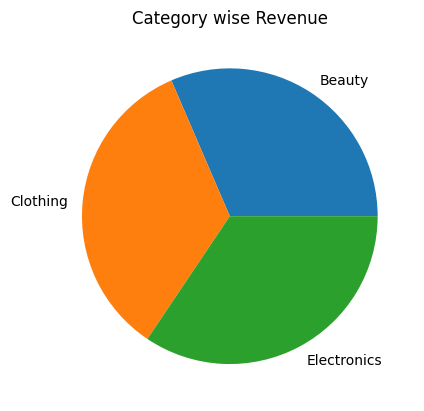

In [109]:
file.groupby("Product Category")["Revenue"].sum().plot(kind="pie")
plt.title("Category wise Revenue")
plt.xlabel("")
plt.ylabel("")

## Top product Visualization

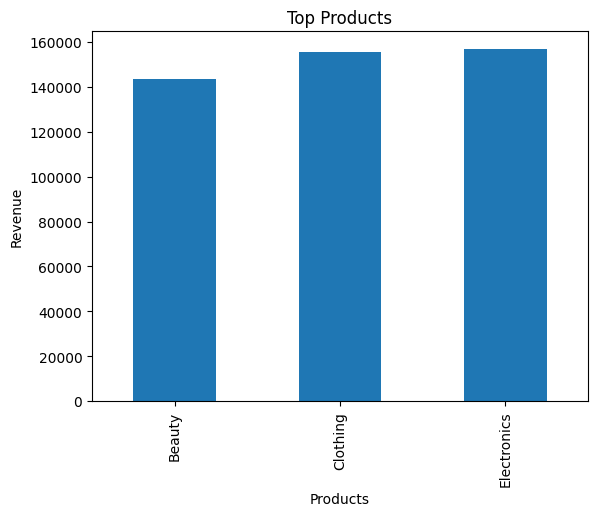

In [103]:
top_products = file.groupby("Product Category")["Revenue"].sum()

top_products.plot(kind="bar")

plt.title("Top Products")
plt.xlabel("Products")
plt.ylabel("Revenue")

plt.show()

- Total Orders

In [96]:
file["Customer ID"].count()

1000